# $(SA) Regular$

$loss = \alpha \times mse(\hat{\theta_i^a}, \hat{\theta_j^a}) + \beta \times (1-mse(\hat{\theta_i^a}, \hat{\theta_k^b})) + \gamma \times mse(\hat{s_{i+2}^a}, y) + \lambda(\hat{\theta_i^a}^2 + \hat{\theta_k^b}^2 + \hat{\theta_j^a}^2)$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Model
from pmbrl.data import Experiment_Data

# Training

In [2]:
data = Experiment_Data()

data.generate_episodes(10)
data.build_training_dataset()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__
123,18,4,"(0.67, 0.6)","[0.089, 0.751, 0.102, -0.53]",1,1.0,"[0.104, 0.949, 0.091, -0.897]",0.0,1.0,"[0.123, 0.747, 0.073, -0.443]"
81,27,3,"(0.28, 1.6)","[0.112, 0.163, -0.062, -0.157]",0,1.0,"[0.116, -0.023, -0.065, -0.059]",0.0,1.0,"[0.115, -0.21, -0.066, 0.038]"
96,42,3,"(0.28, 1.6)","[-0.185, -1.141, 0.075, 0.536]",1,1.0,"[-0.208, -0.955, 0.085, 0.439]",0.0,1.0,"[-0.227, -1.142, 0.094, 0.554]"
132,27,4,"(0.67, 0.6)","[0.247, 1.344, -0.02, -1.574]",1,1.0,"[0.274, 1.545, -0.051, -2.001]",0.0,1.0,"[0.305, 1.345, -0.091, -1.607]"
18,18,0,"(0.54, 1.7)","[0.3, 1.891, -0.156, -1.326]",1,1.0,"[0.338, 2.079, -0.182, -1.471]",1.0,1.0,"[0.379, 2.267, -0.212, -1.617]"
...,...,...,...,...,...,...,...,...,...,...
52,14,2,"(0.65, 1.0)","[0.082, 1.138, -0.114, -1.524]",1,1.0,"[0.105, 1.332, -0.145, -1.795]",1.0,1.0,"[0.131, 1.525, -0.181, -2.07]"
92,38,3,"(0.28, 1.6)","[-0.057, -1.887, 0.012, 0.939]",1,1.0,"[-0.094, -1.7, 0.031, 0.835]",1.0,1.0,"[-0.128, -1.514, 0.047, 0.733]"
1,1,0,"(0.54, 1.7)","[0.007, 0.201, 0.04, -0.138]",0,1.0,"[0.011, 0.013, 0.037, -0.006]",1.0,1.0,"[0.011, 0.2, 0.037, -0.128]"
86,32,3,"(0.28, 1.6)","[0.091, -0.768, -0.058, 0.331]",0,1.0,"[0.076, -0.955, -0.051, 0.43]",0.0,1.0,"[0.057, -1.141, -0.043, 0.529]"


In [3]:
model = Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=500, alpha=loss_param, beta=loss_param, lambda_=loss_param)
train_data = data.get_training_data(trainer)
train_data.head()

,epoch,mse_positive,mse_negative,mse_s,regularize,transition,reward
0,0,"[0.6509144902229309, 2.1583516597747803]","[0.6261458396911621, 2.1860969066619873]","[0.0241562332957983, 0.9550915956497192, 0.080...",1.915454,1.987696,0.315418
1,1,"[0.6547812223434448, 2.1486058235168457]","[0.6297842860221863, 2.176023006439209]","[0.023672999814152718, 0.9431242346763611, 0.0...",1.915357,1.967895,0.313598
2,2,"[0.6586999297142029, 2.138911724090576]","[0.6334762573242188, 2.165992498397827]","[0.023190326988697052, 0.931280791759491, 0.07...",1.915302,1.948243,0.311781
3,3,"[0.6626805067062378, 2.129262685775757]","[0.6372411251068115, 2.1559927463531494]","[0.022706015035510063, 0.9195727109909058, 0.0...",1.915290,1.928737,0.309965
4,4,"[0.6667168140411377, 2.119699239730835]","[0.6410648226737976, 2.1460440158843994]","[0.022232314571738243, 0.9079586863517761, 0.0...",1.915321,1.909368,0.308156


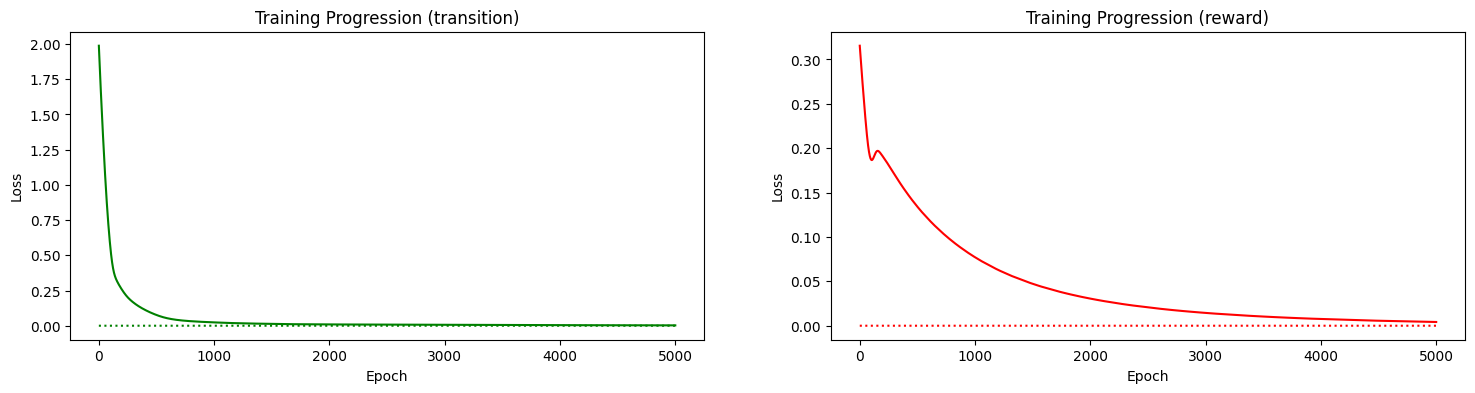

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

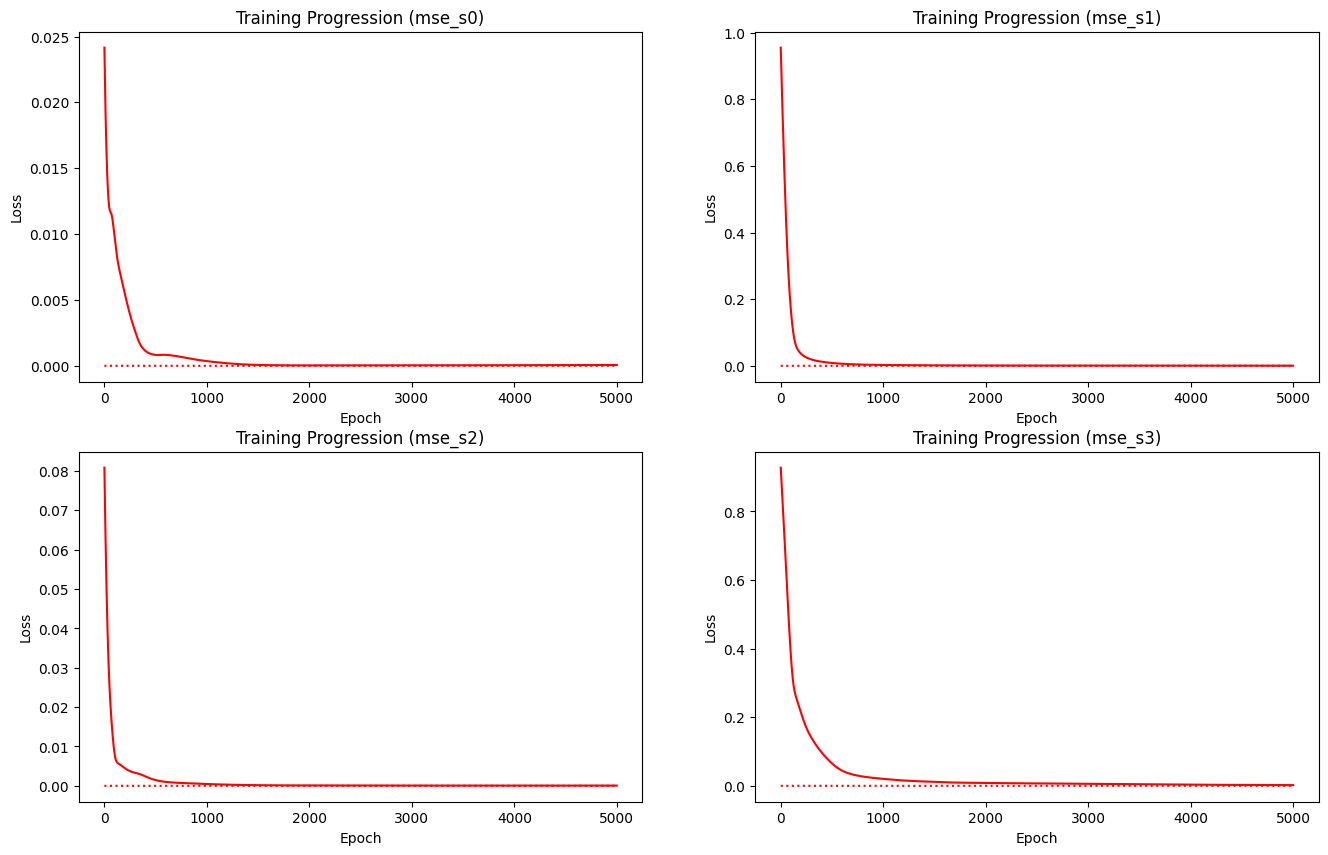

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = data.get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

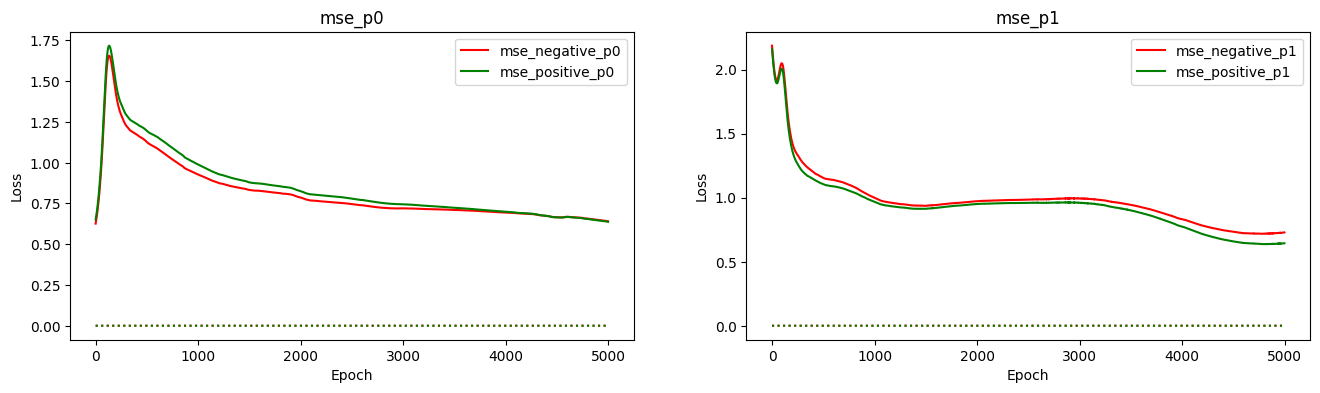

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = data.get_data_expanded(train_data, expansions)

for i,(neg, pos) in enumerate(zip(expansions['mse_negative'], expansions['mse_positive'])):
    data.plot_training_loss(axs[i], df[neg], 'r')
    data.plot_training_loss(axs[i], df[pos], 'g')
    axs[i].set_title(f'mse_p{i}')
    axs[i].legend()

plt.show()

# Evaluation

In [7]:
results = data.evaluate_model(model, n_episodes=10)
results.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__,estimated_s,estimated_p,estimated_r
0,0,0,"(0.03, 0.4)","[0.013, -0.033, -0.012, -0.023]",0,1.0,"[0.013, -0.23, -0.012, 0.321]",0.0,1.0,"[0.008, -0.428, -0.006, 0.664]","[0.012, -0.412, -0.012, 0.516]","(-0.04, 0.52)",0.9
1,1,0,"(0.03, 0.4)","[0.013, -0.23, -0.012, 0.321]",0,1.0,"[0.008, -0.428, -0.006, 0.664]",0.0,1.0,"[-0.0, -0.625, 0.007, 1.01]","[0.006, -0.604, -0.001, 0.942]","(0.23, 0.44)",0.9
2,2,0,"(0.03, 0.4)","[0.008, -0.428, -0.006, 0.664]",0,1.0,"[-0.0, -0.625, 0.007, 1.01]",1.0,1.0,"[-0.013, -0.428, 0.028, 0.665]","[-0.006, -0.419, 0.024, 0.845]","(0.5, 0.34)",0.9
3,3,0,"(0.03, 0.4)","[-0.0, -0.625, 0.007, 1.01]",1,1.0,"[-0.013, -0.428, 0.028, 0.665]",1.0,1.0,"[-0.021, -0.23, 0.041, 0.327]","[-0.019, -0.231, 0.043, 0.449]","(0.21, 0.37)",0.9
4,4,0,"(0.03, 0.4)","[-0.013, -0.428, 0.028, 0.665]",1,1.0,"[-0.021, -0.23, 0.041, 0.327]",0.0,1.0,"[-0.026, -0.429, 0.048, 0.69]","[-0.024, -0.417, 0.043, 0.467]","(-0.09, 0.46)",0.9


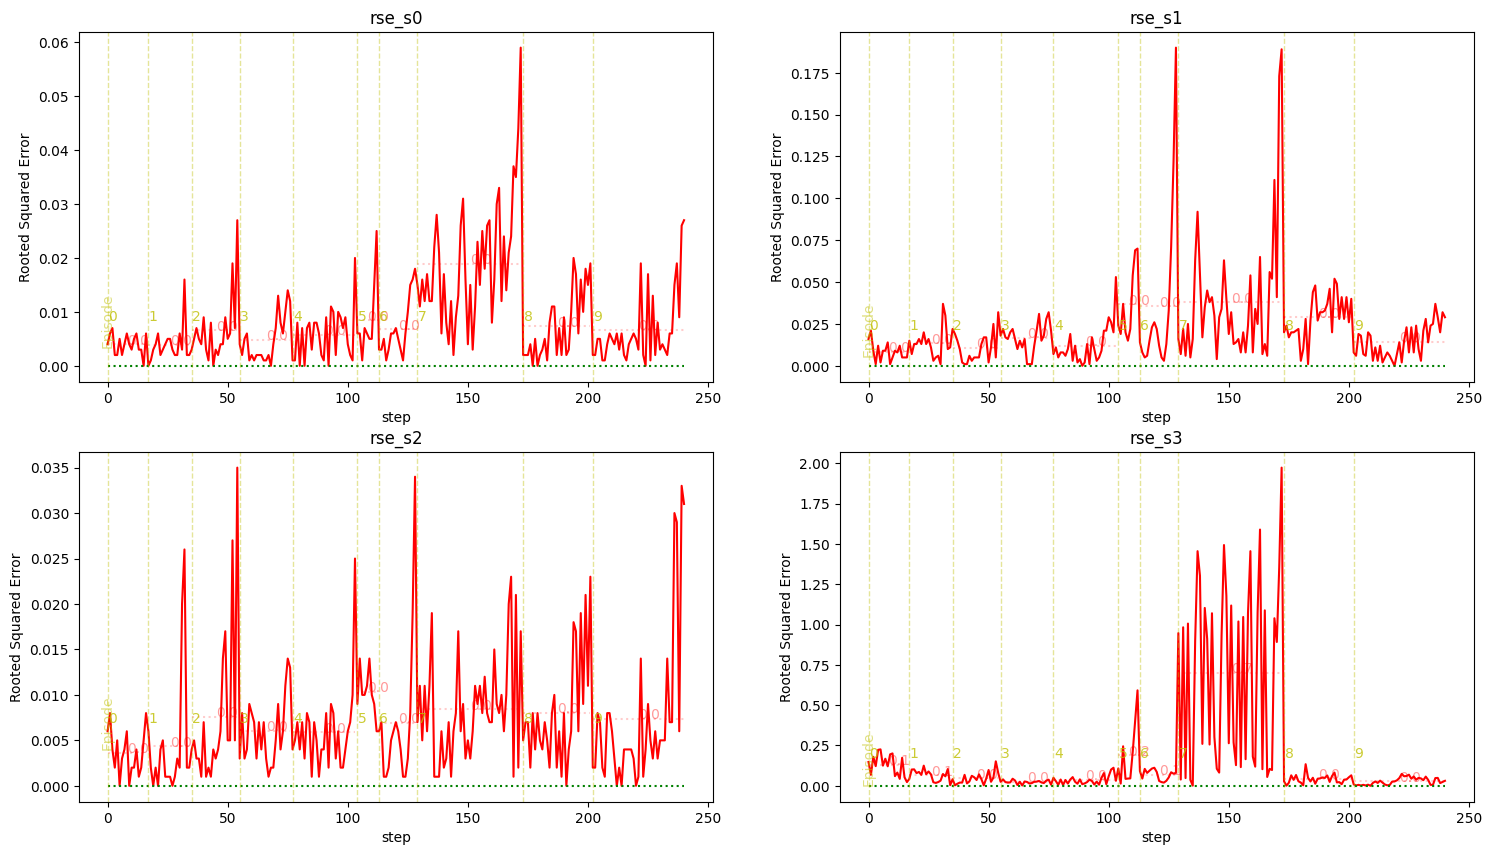

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3')

plt.show()

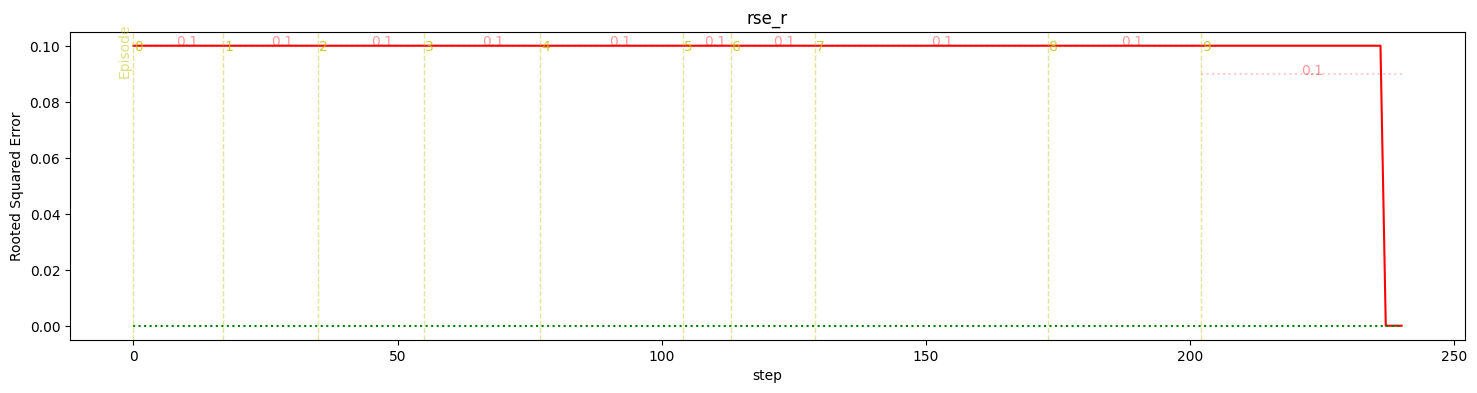

In [9]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

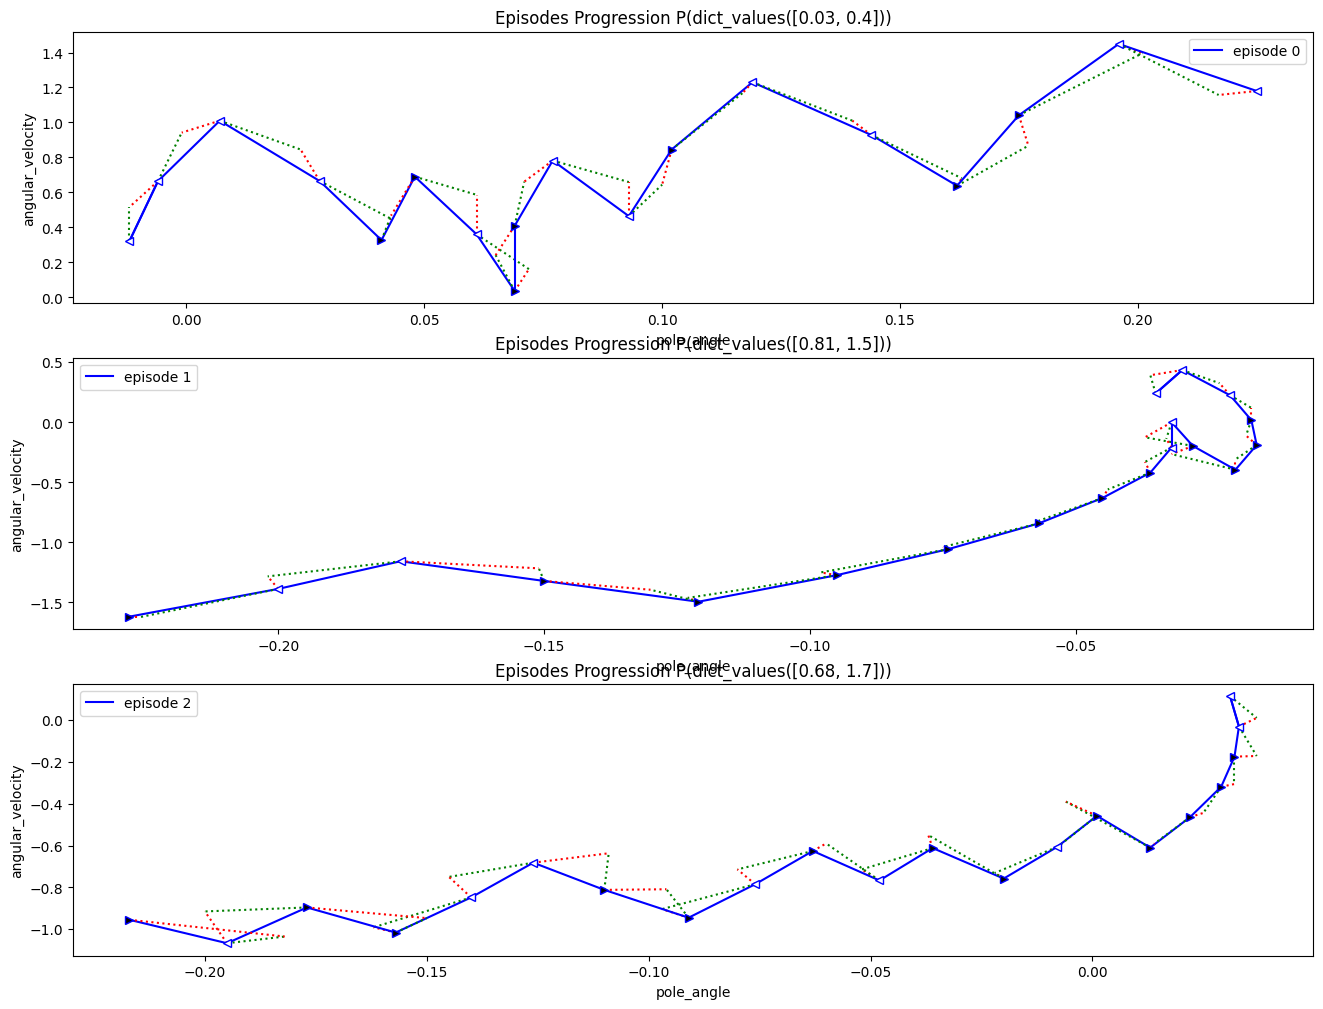

In [10]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()